<a href="https://colab.research.google.com/github/Ymin-2/ESAA/blob/main/ESAA_OB_WEEK12_2_NLP_GM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **9. 자연어 전처리**

## **9.1 자연어 처리란**

자연어 처리: 일상생활에서 사용하는 언어 의미를 분석하여 컴퓨터가 처리할 수 있도록 하는 과정

### 9.1.1 자연어 처리 용어 및 과정

- 말뭉치(corpus(코퍼스)): 자연어 처리에서 모델을 학습시키기 위한 데이터, 자연어 연구를 위해 특정한 목적에서 표본을 추출한 집합
- 토큰(token): 자연어 처리를 위한 문서는 작은 단위로 나누어야 하는데, 이때 문서를 나누는 단위가 토큰
- 토큰화(tokenization): 텍스트를 문장이나 단어로 분리하는 것
- 불용어(stop words): 문장 내에서 많이 등장하는 단어
- 어간 추출(stemming): 단어를 기본 형태로 만드는 작업
- 품사 태깅(part-of-speech tagging): 주어진 문장에서 품사를 식별하기 위해 붙여 주는 태그

In [ ]:
# 9-1 문장 토큰화
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
text = nltk.word_tokenize("Is it possible distinguishing cats and dogs")
text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Is', 'it', 'possible', 'distinguishing', 'cats', 'and', 'dogs']

In [ ]:
# 9-2 태깅에 필요한 자원 내려받기
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# 9-3 품사 태깅
nltk.pos_tag(text)

[('Is', 'VBZ'),
 ('it', 'PRP'),
 ('possible', 'JJ'),
 ('distinguishing', 'VBG'),
 ('cats', 'NNS'),
 ('and', 'CC'),
 ('dogs', 'NNS')]

**자연어 처리 과정**

1. 인간 언어인 자연어가 입력 텍스트로 들어옴
2. 입력된 텍스트에 대한 전처리 과정 필요
3. 전처리가 끝난 단어들을 임베딩
4. 컴퓨터가 이해할 수 있는 데이터가 완성되었기 때문에 모델/모형을 이용해 데이터에 대한 분류 및 예측 수행

### 9.1.2 자연어 처리를 위한 라이브러리

**NLTK**

: 교육용으로 개발된 자연어 처리 및 문서 분석용 파이썬 라이브러리

In [ ]:
# 9-4 nltk 라이브러리 호출 및 문장 정의
import nltk
nltk.download('punkt')
string1 = 'my favorite subject is math'
string2 = 'my favorite subject is math, english, economic and computer science'
nltk.word_tokenize(string1)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['my', 'favorite', 'subject', 'is', 'math']

In [ ]:
# 9-5 단어 단위로 분리
nltk.word_tokenize(string2)

['my',
 'favorite',
 'subject',
 'is',
 'math',
 ',',
 'english',
 ',',
 'economic',
 'and',
 'computer',
 'science']

**KoNLPy**

: 한국어 처리를 위한 파이썬 라이브러리

In [ ]:
# 9-6 라이브러리 호출 및 문장을 형태소로 변환
!pip install konlpy
from konlpy.tag import Komoran
komoran = Komoran()
print(komoran.morphs('딥러닝이 쉽나요? 어렵나요?'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.1 MB/s eta 0:00:00
['딥러닝이', '쉽', '나요', '?', '어렵', '나요', '?']


In [ ]:
# 9-7 품사 태깅
print(komoran.pos('소파 위에 있는 것이 고양이인가요? 강아지인가요?'))

[('소파', 'NNP'), ('위', 'NNG'), ('에', 'JKB'), ('있', 'VV'), ('는', 'ETM'), ('것', 'NNB'), ('이', 'JKS'), ('고양이', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF'), ('강아지', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF')]


**Gensim**

: 파이썬에서 제공하는 워드투벡터 라이브러리

**사이킷런**

: 파이썬을 이용하여 문서를 전처리할 수 있는 라이브러리 제공

# **13. 생성 모델**

## **13.1 생성 모델이란**

생성모델(generative model): 주어진 데이터를 학습하여 데이터 분포를 따르는 유사한 데이터를 생성하는 모델

### 13.1.1 생성 모델 개념

판별 모델: 이미지를 분류하는 것

생성 모델: 판별자 모델에서 추출한 특성들의 조합을 이용하여 새로운 개와 고양이 이미지를 생성할 수 있음  
입력 이미지에 대한 데이터 분포를 학습해 새로운 이미지를 생성하는 것

### 13.1.2 생성 모델의 유형

모델의 확률 변수를 구하는 '변형 오토인코더 모델'  
: 이미지의 잠재 공간에서 샘플링하여 완전히 새로운 이미지나 기존 이미지를 변형하는 방식으로 학습 진행  
확률 변수를 이용하지 않는 'GAN 모델'  
: 생성자와 판별자가 서로 경쟁하면서 가짜 이미지를 진짜 이미지와 최대한 비슷하게 만들도록 학습 진행

- 명시적 방법: 확률 변수를 정의하여 사용
- 암시적 방법: 확률 변수에 대한 정의 없이 확률변수를 샘플링하여 사용

## **13.2 변형 오토인코더**

### 13.2.1 오토인코더란

오토인코더: 단순히 입력을 출력으로 복사하는 신경망으로 은닉층의 노드 수가 입력 값보다 적은 것이 특징  
--> 입력과 출력이 동일한 이미지라고 예상할 수 있음

오토인코더의 병목층은 입력과 출력의 뉴런보다 훨씬 적음  
--> 적은 수의 병목층 뉴런으로 데이터를 가장 잘 표현할 수 있음

구성
1. 인코더(인지 네트워크): 특성에 대한 학습 수행
2. 병목층(은닉층): 모델의 뉴런 개수가 최소인 계층
3. 디코더(생성 네트워크): 병목층에서 압축된 데이터를 원래대로 재구성하는 역할
4. 손실 재구성: 오토인코더는 입력층과 출력층의 뉴런 개수가 동일하다는 것만 제외하면 일반적인 다층 퍼셉트론과 구조가 동일. 오토인코더는 압축된 입력을 출력층에서 재구성하며 손실함수는 입력과 출력의 차이를 가지고 계산

오토인코더가 중요한 이유
1. 데이터 압축
2. 차원의 저주 예방: 차원이 감소해 차원의 저주 예방
3. 특성 추출

In [ ]:
# 13-1 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 13-2 MNIST 데이터셋을 내려받아 전처리
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, num_workers=4, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size = 128, shuffle = False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.34MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.95MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# 13-3 네트워크(신경망) 생성
class Encoder(nn.Module):
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super().__init__()

    self.encoder_cnn = nn.Sequential(
        nn.Conv2d(1, 8, 3, stride = 2, padding = 1),
        nn.ReLU(True),
        nn.Conv2d(8, 16, 3, stride = 2, padding = 1),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.Conv2d(16, 32, 3, stride = 2, padding = 0),
        nn.ReLU(True)
    )

    self.flatten = nn.Flatten(start_dim = 1) # 완전연결층)
    self.encoder_lin = nn.Sequential(
        nn.Linear(3*3*32, 128),
        nn.ReLU(True),
        nn.Linear(128, encoded_space_dim)
    ) # 출력 계층

  def forward(self, x):
    x = self.encoder_cnn(x)
    x = self.flatten(x)
    x = self.encoder_lin(x)
    return x

class Decoder(nn.Module):
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super().__init__()
    self.decoder_lin = nn.Sequential(
        nn.Linear(encoded_space_dim, 128),
        nn.ReLU(True),
        nn.Linear(128, 3*3*32),
        nn.ReLU(True)
    ) # 인코더의 출력을 디코더의 입력으로 사용

    self.unflatten = nn.Unflatten(dim=1,
                                  unflattened_size=(32, 3, 3)) # 인코더의 완전연결층에 대응
    self.decoder_conv = nn.Sequential(
        nn.ConvTranspose2d(32, 16, 3, stride = 2, output_padding = 0),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.ConvTranspose2d(16, 8, 3, stride = 2, padding = 1, output_padding = 1),
        nn.BatchNorm2d(8),
        nn.ReLU(True),
        nn.ConvTranspose2d(8, 1, 3, stride = 2, padding = 1, output_padding = 1)
    ) # 인코더의 합성곱층에 대응

  def forward(self, x):
    x = self.decoder_lin(x)
    x = self.unflatten(x)
    x = self.decoder_conv(x)
    x = torch.sigmoid(x)
    return x

In [ ]:
# 13-4 손실 함수와 옵티마이저 지정
encoder = Encoder(encoded_space_dim = 4, fc2_input_dim = 128)
decoder = Decoder(encoded_space_dim = 4, fc2_input_dim = 128)
encoder.to(device)
decoder.to(device)

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
] # 인코더와 디코더에서 사용할 파라미터를 다르게 지정
optim = torch.optim.Adam(params_to_optimize, lr=0.001, weight_decay = 1e-05)
loss_fn = torch.nn.MSELoss()

In [ ]:
# 13-5 모델 학습 함수 생성
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer, noise_factor=0.3):
  encoder.train()
  decoder.train()
  train_loss = []
  for image_batch, _ in dataloader:
    image_noisy = add_noise(image_batch, noise_factor)
    image_noisy = image_noisy.to(device)
    encoded_data = encoder(image_noisy)
    decoded_data = decoder(encoded_data)
    loss = loss_fn(decoded_data, image_noisy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.detach().cpu().numpy())
  return np.mean(train_loss)

In [ ]:
# 13-6 모델 테스트 함수 생성
def test_epoch(encoder, decoder, device, dataloader, loss_fn, noise_factor=0.3):
  # Set evaluation mode for encoder and decoder
  encoder.eval()
  decoder.eval()
  with torch.no_grad():
    conc_out = []
    conc_label = []
    for image_batch, _ in dataloader:
      image_batch = image_batch.to(device)
      encoded_data = encoder(image_batch)
      decoded_data = decoder(encoded_data)
      conc_out.append(decoded_data.cpu())
      conc_label.append(image_batch.cpu())
    conc_out = torch.cat(conc_out)
    conc_label = torch.cat(conc_label)
    val_loss = loss_fn(conc_out, conc_label)
  return val_loss.data

In [ ]:
# 13-7 노이즈 데이터 생성
def add_noise(inputs, noise_factor=0.3):
  noisy = inputs + torch.randn_like(inputs) * noise_factor
  noisy = torch.clip(noisy, 0., 1.)
  return noisy

In [ ]:
# 13-8 한글 깨짐 문제 해결
# 한글 폰트 설치
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 경로
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

font_family = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_family

In [ ]:
# 13-9 이미지 시각화
def plot_ae_outputs(encoder, decoder, n=5, noise_factor=0.3):
  plt.figure(figsize = (10, 4.5))
  for i in range(n):
    ax = plt.subplot(3, n, i+1)
    img = test_dataset[i][0].unsqueeze(0)
    image_noisy = add_noise(img, noise_factor)
    image_noisy = image_noisy.to(device)

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
      rec_img = decoder(encoder(image_noisy))

    plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('원래 이미지')
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(image_noisy.cpu().squeeze().numpy(), cmap='gist_gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if 1 == n//2:
      ax.set_title('노이즈가 적용되어 손상된 이미지')

    ax = plt.subplot(3, n, i+1+n+n)
    plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('재구성된 이미지')
  plt.subplots_adjust(left =0.1, bottom=0.1, right=0.7,
                      top=0.9, wspace = 0.3, hspace = 0.3)
  plt.show()

EPOCH 1/30



 EPOCH 1/30 	 train loss 0.057 	 val loss 0.049


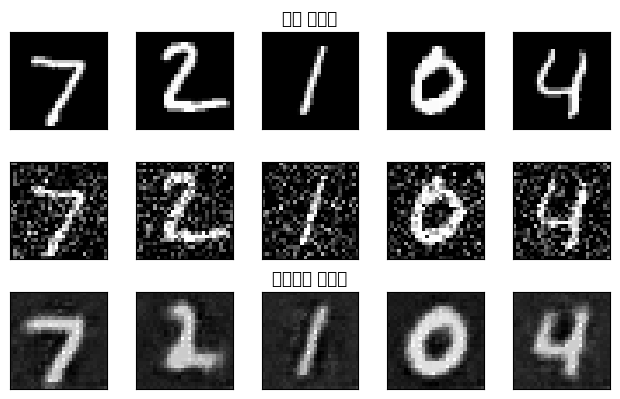

EPOCH 2/30



 EPOCH 2/30 	 train loss 0.055 	 val loss 0.047


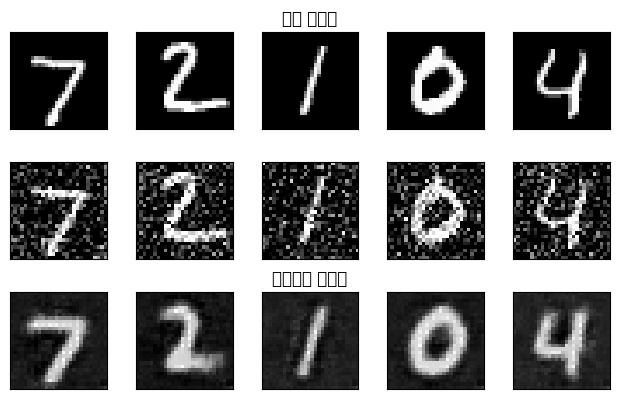

EPOCH 3/30



 EPOCH 3/30 	 train loss 0.054 	 val loss 0.045


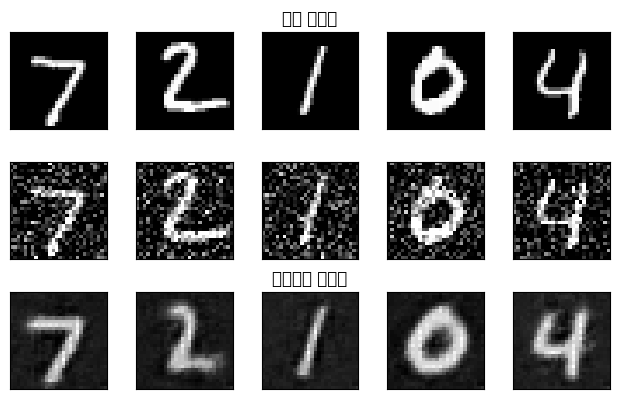

EPOCH 4/30



 EPOCH 4/30 	 train loss 0.053 	 val loss 0.043


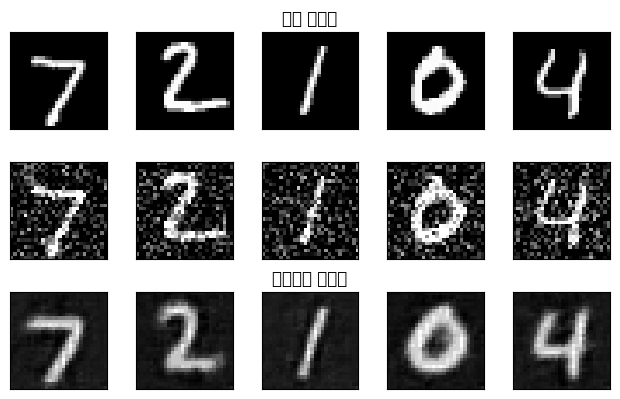

EPOCH 5/30

 EPOCH 5/30 	 train loss 0.052 	 val loss 0.042


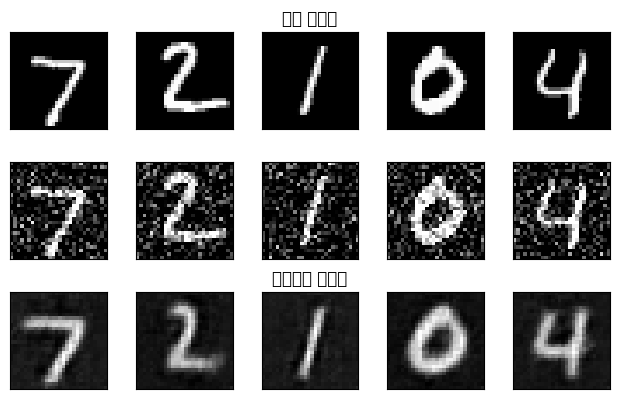

EPOCH 6/30

 EPOCH 6/30 	 train loss 0.052 	 val loss 0.041


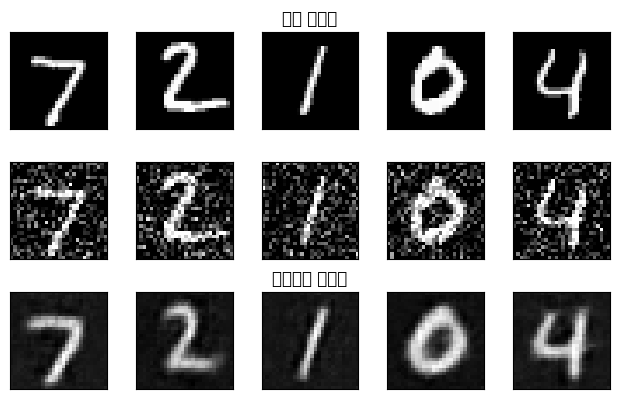

EPOCH 7/30



 EPOCH 7/30 	 train loss 0.051 	 val loss 0.041


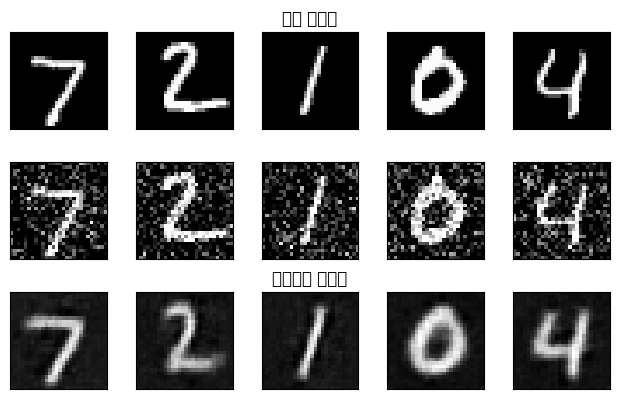

EPOCH 8/30



 EPOCH 8/30 	 train loss 0.051 	 val loss 0.040


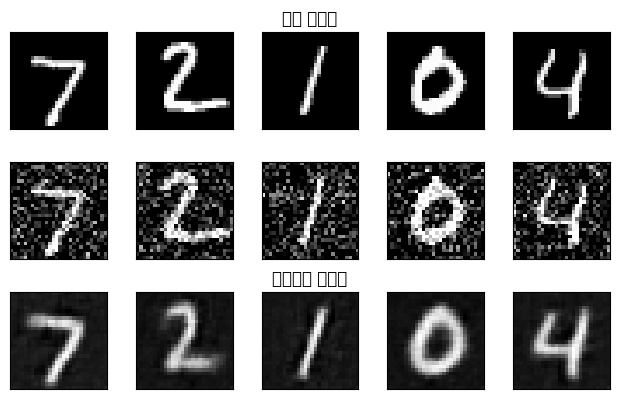

EPOCH 9/30



 EPOCH 9/30 	 train loss 0.051 	 val loss 0.040


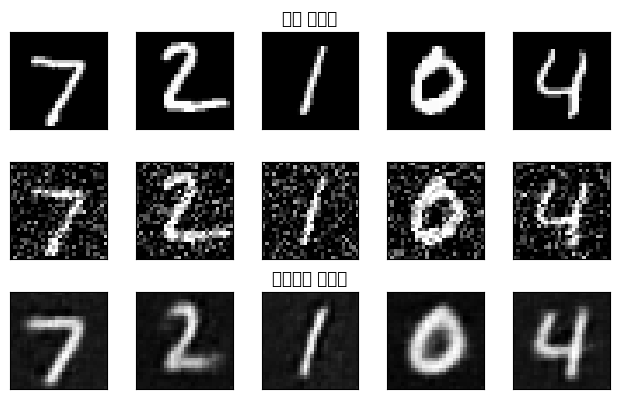

EPOCH 10/30

 EPOCH 10/30 	 train loss 0.051 	 val loss 0.040


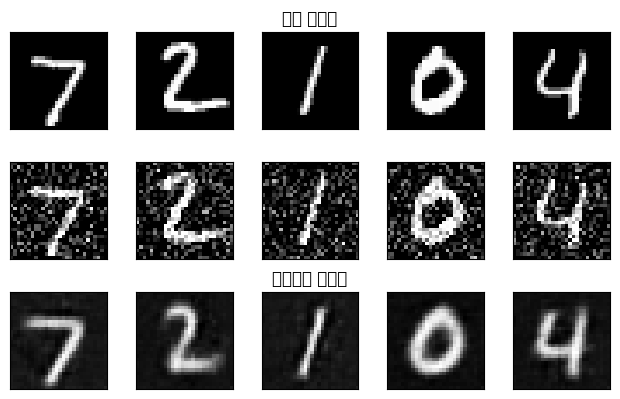

EPOCH 11/30

 EPOCH 11/30 	 train loss 0.050 	 val loss 0.039


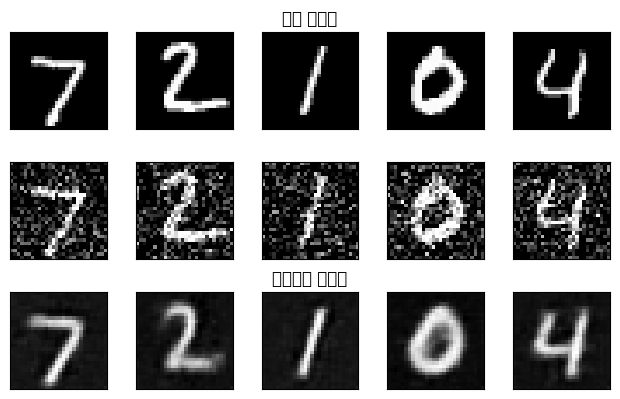

EPOCH 12/30

 EPOCH 12/30 	 train loss 0.050 	 val loss 0.039


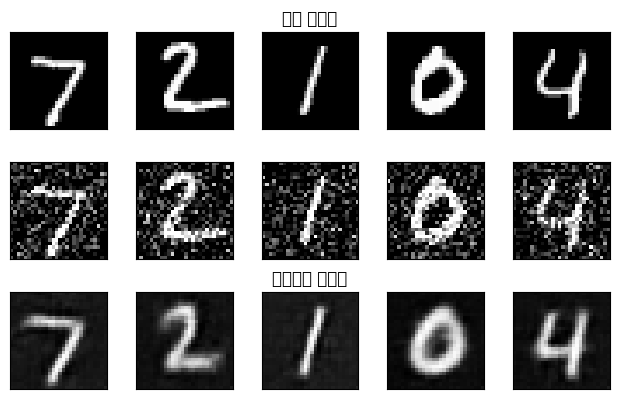

EPOCH 13/30

 EPOCH 13/30 	 train loss 0.050 	 val loss 0.039


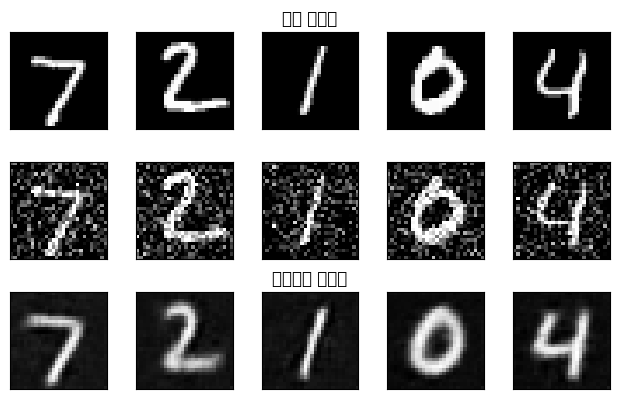

EPOCH 14/30

 EPOCH 14/30 	 train loss 0.050 	 val loss 0.039


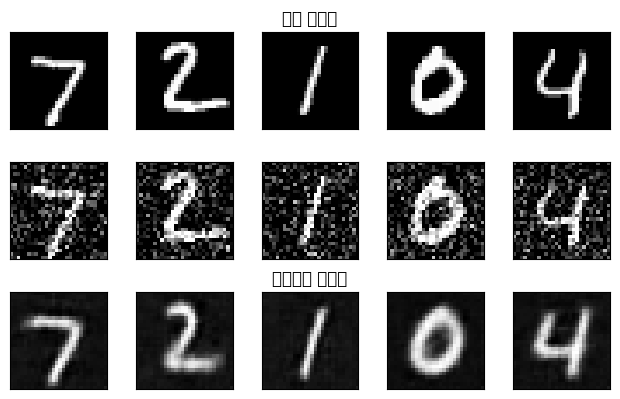

EPOCH 15/30

 EPOCH 15/30 	 train loss 0.050 	 val loss 0.039


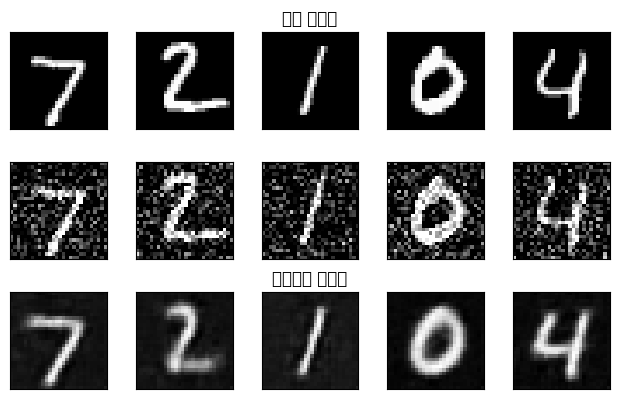

EPOCH 16/30



 EPOCH 16/30 	 train loss 0.050 	 val loss 0.038


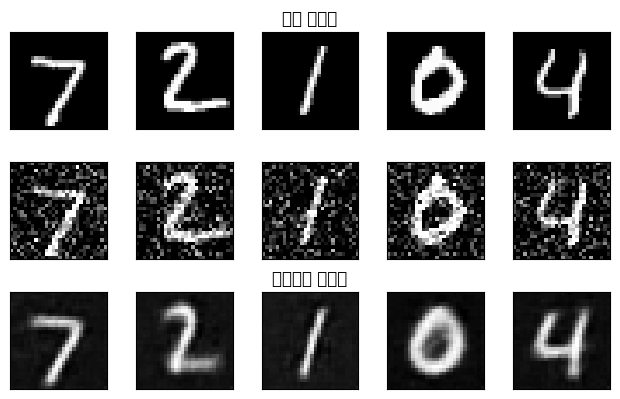

EPOCH 17/30



 EPOCH 17/30 	 train loss 0.050 	 val loss 0.038


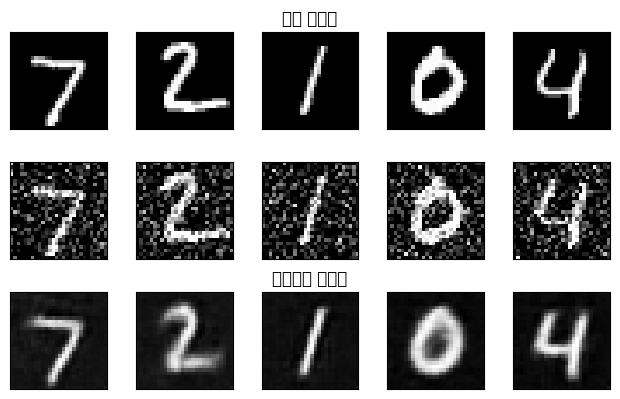

EPOCH 18/30



 EPOCH 18/30 	 train loss 0.050 	 val loss 0.038


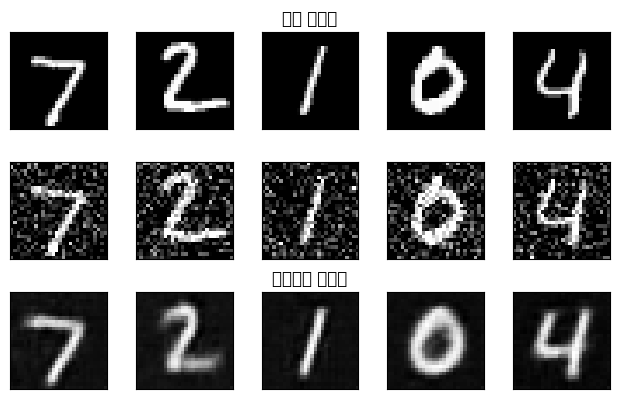

EPOCH 19/30

 EPOCH 19/30 	 train loss 0.050 	 val loss 0.039


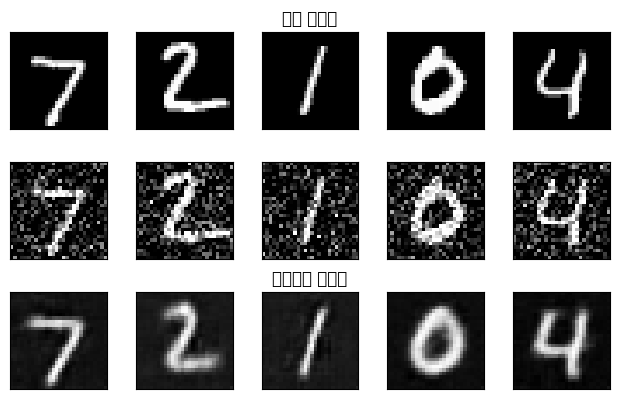

EPOCH 20/30



 EPOCH 20/30 	 train loss 0.050 	 val loss 0.038


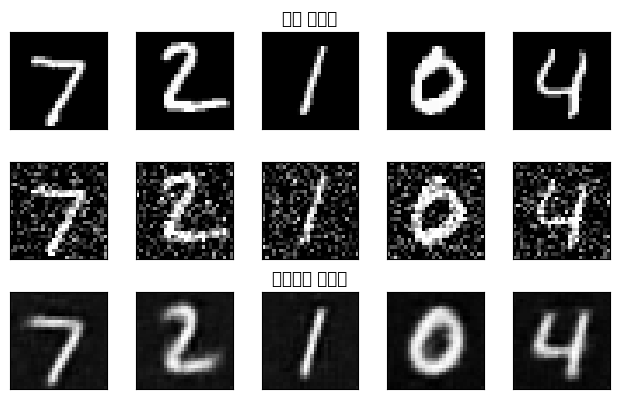

EPOCH 21/30



 EPOCH 21/30 	 train loss 0.050 	 val loss 0.038


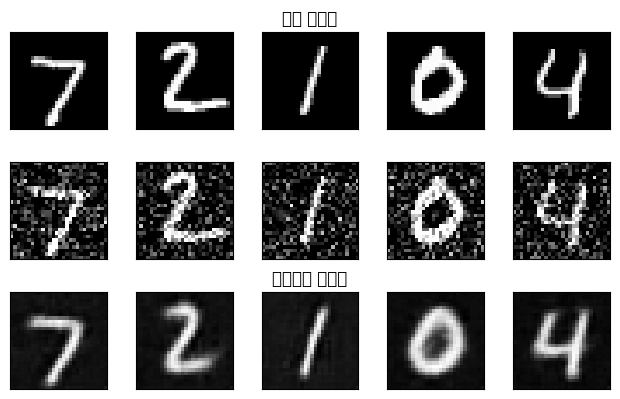

EPOCH 22/30



 EPOCH 22/30 	 train loss 0.050 	 val loss 0.038


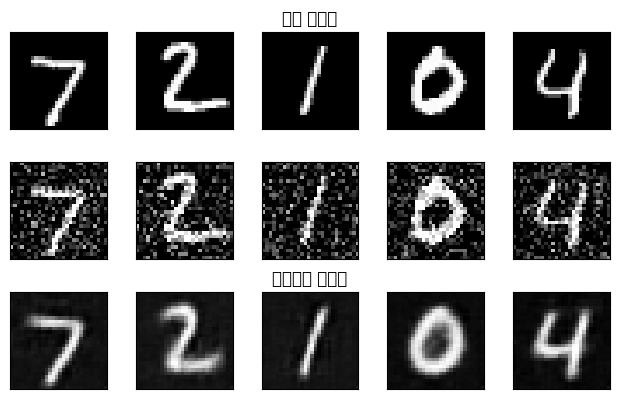

EPOCH 23/30



 EPOCH 23/30 	 train loss 0.050 	 val loss 0.038


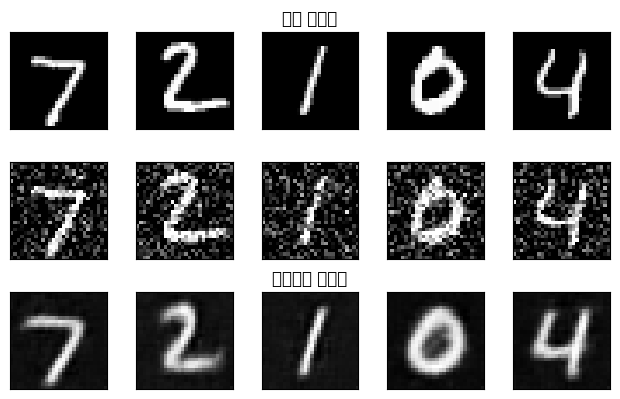

EPOCH 24/30



 EPOCH 24/30 	 train loss 0.050 	 val loss 0.039


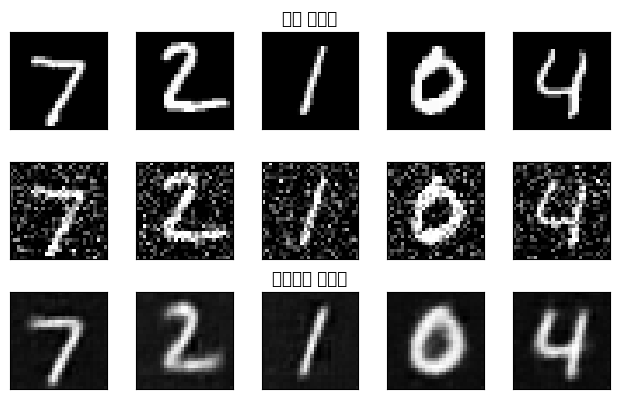

EPOCH 25/30

 EPOCH 25/30 	 train loss 0.050 	 val loss 0.038


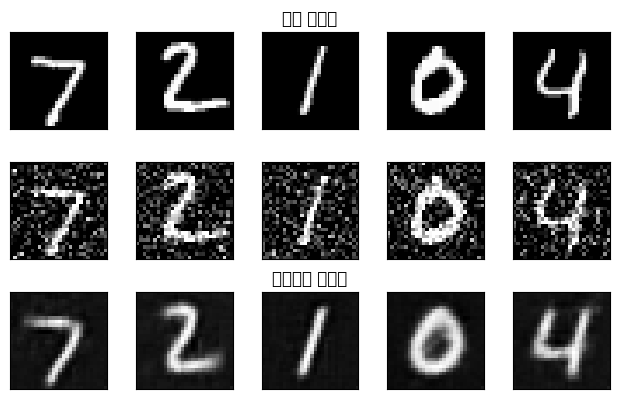

EPOCH 26/30

 EPOCH 26/30 	 train loss 0.050 	 val loss 0.038


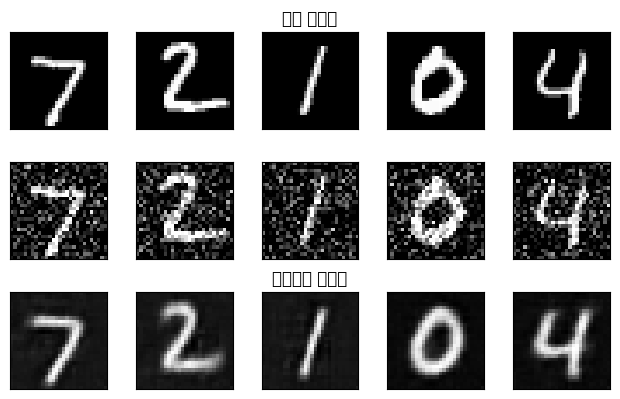

EPOCH 27/30



 EPOCH 27/30 	 train loss 0.050 	 val loss 0.038


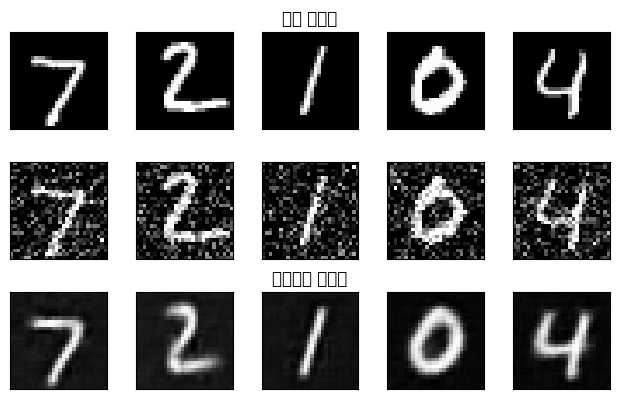

EPOCH 28/30

 EPOCH 28/30 	 train loss 0.049 	 val loss 0.039


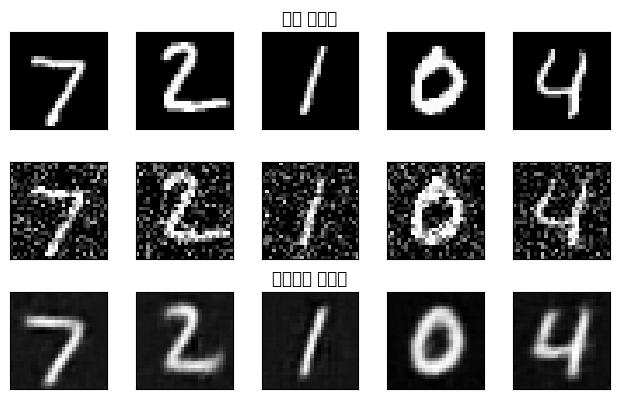

EPOCH 29/30



 EPOCH 29/30 	 train loss 0.049 	 val loss 0.038


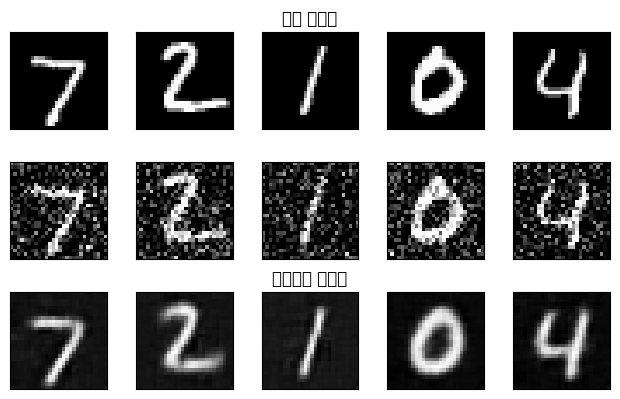

EPOCH 30/30



 EPOCH 30/30 	 train loss 0.049 	 val loss 0.038


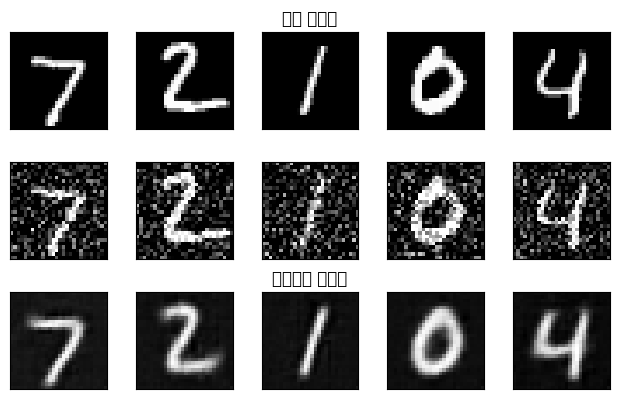

In [ ]:
# 13-10 모델 학습
import numpy as np

num_epochs = 30
history_da = {'train_loss':[], 'val_loss': []}
loss_fn = torch.nn.MSELoss()

for epoch in range(num_epochs):
  print('EPOCH %d/%d' % (epoch + 1, num_epochs))
  train_loss = train_epoch(
      encoder = encoder, decoder = decoder,
      device = device, dataloader = train_loader,
      loss_fn = loss_fn, optimizer = optim,
      noise_factor = 0.3)
  val_loss = test_epoch(
      encoder = encoder, decoder = decoder,
      device = device, dataloader = test_loader,
      loss_fn = loss_fn, noise_factor = 0.3)
  history_da['train_loss'].append(train_loss)
  history_da['val_loss'].append(val_loss)
  print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(
      epoch + 1, num_epochs, train_loss, val_loss))
  plot_ae_outputs(encoder, decoder, noise_factor = 0.3)

### 13.2.2 변형 오토인코더

: 표준편차와 평균을 이용하여 확률 분포를 만들고, 거기에서 샘플링하여 디코더를 통과시킨 후 새로운 데이터를 만들어 냄

In [ ]:
!pip install tensorboardX

In [ ]:
# 13-11 필요한 라이브러리 호출
import datetime
import os
from tensorboardX import SummaryWriter

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cude" if torch.cuda.is_available() else "cpu")

In [ ]:
# 13-12 데이터셋을 내려받은 후 텐서 변환
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=4, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# 13-13 인코더 네트워크 생성
class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.input1 = nn.Linear(input_dim, hidden_dim)
    self.input2 = nn.Linear(hidden_dim, hidden_dim)
    self.mean = nn.Linear(hidden_dim, latent_dim)
    self.var = nn.Linear(hidden_dim, latent_dim)

    self.LeakyReLU = nn.LeakyReLU(0.2)
    self.training = True

  def forward(self, x):
    h_ = self.LeakyReLU(self.input1(x))
    h_ = self.LeakyReLU(self.input2(h_))
    mean = self.mean(h_)
    log_var = self.var(h_)
    return mean, log_var # 인코더 네트워크에서 평균과 분산을 반환

In [ ]:
# 13-14 디코더 네트워크
class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super(Decoder, self).__init__()
    self.hidden1 = nn.Linear(latent_dim, hidden_dim)
    self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
    self.output = nn.Linear(hidden_dim, output_dim)
    self.LeakyReLU = nn.LeakyReLU(0.2)

  def forward(self, x):
    h = self.LeakyReLU(self.hidden1(x))
    h = self.LeakyReLU(self.hidden2(h))
    x_hat = torch.sigmoid(self.output(h))
    return x_hat

In [ ]:
# 13-15 변형 오토인코더 네트워크
class Model(nn.Module):
  def __init__(self, Encoder, Decoder):
    super(Model, self).__init__()
    self.Encoder = Encoder
    self.Decoder = Decoder

  def reparameterization(self, mean, var):
    epsilon = torch.randn_like(var).to(device)
    z = mean + var * epsilon
    return z

  def forward(self, x):
    mean, log_var = self.Encoder(x)
    z = self.reparameterization(mean, torch.exp(0.5 * log_var))
    x_hat = self.Decoder(z)
    return x_hat, mean, log_var

In [ ]:
# 13-16 인코더와 디코더 객체 초기화
x_dim = 784
hidden_dim = 400
latent_dim = 200
epochs = 30
batch_size = 100

encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)

In [ ]:
# 13-17 손실 함수 정의
def loss_function(x, x_hat, mean, log_var):
  reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
  KLD = -0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())
  return reproduction_loss, KLD

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# 13-18 모델 학습 함수 정의
saved_loc = 'scalar/'
writer = SummaryWriter(saved_loc)

model.train()
def train(epoch, model, train_loader, optimizer):
  train_loss = 0
  for batch_idx, (x, _) in enumerate(train_loader):
    x = x.view(batch_size, x_dim)
    x = x.to(device)

    optimizer.zero_grad()
    x_hat, mean, log_var = model(x)
    BCE, KLD = loss_function(x, x_hat, mean, log_var)
    loss = BCE + KLD
    writer.add_scalar("Train/Reconstruction Error", BCE.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    writer.add_scalar("Train/KL-Divergence", KLD.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    writer.add_scalar("Train/Total Loss", loss.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    train_loss += loss.item()
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\t Loss: {:.6f}'.format(
          epoch, batch_idx * len(x), len(train_loader.dataset),
          100. * batch_idx / len(train_loader), loss.item() / len(x)))
  print('====> Epoch: {} Average loss: {:.4f}'.format(
      epoch, train_loss / len(train_loader.dataset)))

In [ ]:
# 13-19 모델 평가 함수 정의
def test(epoch, model, test_loader):
  model.eval()
  test_loss = 0
  with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
      x = x.view(batch_size, x_dim)
      x = x.to(device)
      x_hat, mean, log_var = model(x)
      BCE, KLD = loss_function(x, x_hat, mean, log_var)
      loss = BCE + KLD

      writer.add_scalar("Test/Reconstruction Error", BCE.item(), batch_idx +
                        epoch * (len(test_loader.dataset)/batch_size))
      writer.add_scalar("Test/KL-Divergence", KLD.item(), batch_idx + epoch *
                        (len(test_loader.dataset)/batch_size))
      writer.add_scalar("Test/Total Loss", loss.item(), batch_size + epoch *
                        (len(test_loader.dataset)/batch_size))
      test_loss += loss.item()

      if batch_idx == 0:
        n = min(x.size(0), 8)
        comparison = torch.cat([x[:n], x_hat.view(batch_size, x_dim)[:n]])
        grid = torchvision.utils.make_grid(comparison.cpu())
        writer.add_image("Test image - Above: Real data, below: reconstruction data", grid, epoch)

In [ ]:
# 13-20 모델 학습
from tqdm.auto import tqdm
for epoch in tqdm(range(0, epochs)):
  train(epoch, model, train_loader, optimizer)
  test(epoch, model, test_loader)
  print("\n")
writer.close()

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Epoch: 0 [0/60000 (0%)]	 Loss: 139.021514
Train Epoch: 0 [10000/60000 (17%)]	 Loss: 139.826455
Train Epoch: 0 [20000/60000 (33%)]	 Loss: 128.860957
Train Epoch: 0 [30000/60000 (50%)]	 Loss: 127.813691
Train Epoch: 0 [40000/60000 (67%)]	 Loss: 123.852314
Train Epoch: 0 [50000/60000 (83%)]	 Loss: 118.315430
====> Epoch: 0 Average loss: 128.2689


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()




Train Epoch: 1 [0/60000 (0%)]	 Loss: 124.294316
Train Epoch: 1 [10000/60000 (17%)]	 Loss: 121.442314
Train Epoch: 1 [20000/60000 (33%)]	 Loss: 119.670566
Train Epoch: 1 [30000/60000 (50%)]	 Loss: 120.312031
Train Epoch: 1 [40000/60000 (67%)]	 Loss: 112.732930
Train Epoch: 1 [50000/60000 (83%)]	 Loss: 116.147969
====> Epoch: 1 Average loss: 116.6333


Train Epoch: 2 [0/60000 (0%)]	 Loss: 111.449219
Train Epoch: 2 [10000/60000 (17%)]	 Loss: 115.263320
Train Epoch: 2 [20000/60000 (33%)]	 Loss: 114.181992
Train Epoch: 2 [30000/60000 (50%)]	 Loss: 111.726572
Train Epoch: 2 [40000/60000 (67%)]	 Loss: 110.360830
Train Epoch: 2 [50000/60000 (83%)]	 Loss: 110.491270
====> Epoch: 2 Average loss: 112.8058


Train Epoch: 3 [0/60000 (0%)]	 Loss: 108.091914
Train Epoch: 3 [10000/60000 (17%)]	 Loss: 115.658867
Train Epoch: 3 [20000/60000 (33%)]	 Loss: 108.789199
Train Epoch: 3 [30000/60000 (50%)]	 Loss: 115.300410
Train Epoch: 3 [40000/60000 (67%)]	 Loss: 109.593848
Train Epoch: 3 [50000/60000 (83%

In [ ]:
# 13-21 텐서보드에서 오차 확인
%load_ext tensorboard
%tensorboard --logdir scalar --port = 6013

ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
2026-05-15 13:32:43.354620: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-15 13:32:43.538548: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
                   [--host ADDR] [--bind_all] [--port PORT]
                   [--reuse_port BOOL] [--load_fast {false,auto,true}]
                   [--extra_data_server_flags EXTRA_DATA_SERVER_FLAGS]
                   [--grpc_creds_type {local,ssl,ssl_dev}]
                   [--grpc_data_provider PORT] [--purge_orphaned_data BOOL]
                   [--db URI] [--db_import] [--insp